In [1]:
"""Customer Segmentation
this project uses the concept of unsupervised learning .
Use clustering (K-Means, Hierarchical, DBSCAN) to group customers based on purchase history or demographics.
Dataset: Mall Customer Segmentation Dataset. """

'Customer Segmentation\nthis project uses the concept of unsupervised learning .\nUse clustering (K-Means, Hierarchical, DBSCAN) to group customers based on purchase history or demographics.\nDataset: Mall Customer Segmentation Dataset. '

In [5]:
# IMPORTING LIBRARIES...

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [9]:
# Load the Dataset

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [11]:
# Exploratory Data Analysis (EDA)

In [13]:
df.info()
df.describe()
df['Gender'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Gender
Female    112
Male       88
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

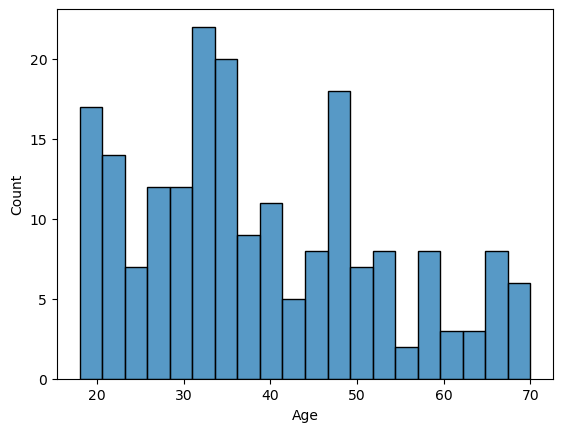

In [19]:
# Data Visualization

sns.histplot(df['Age'], bins=20)

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

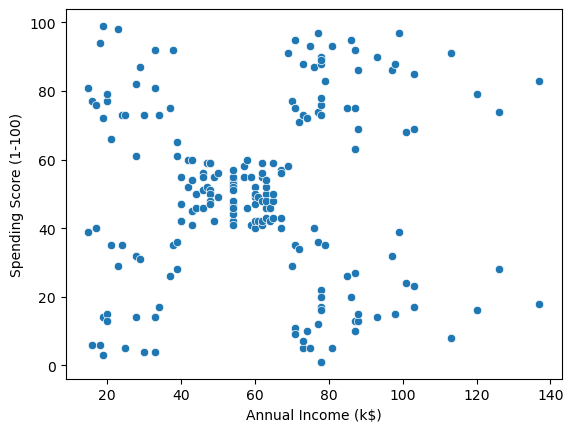

In [21]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)

In [23]:
# Feature Selection

X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [25]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
# K-Means Clustering

wcss = []  # within-cluster sum of squares
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

#  Elbow Method:

#Plot k vs wcss → the “elbow” point shows optimal k (diminishing returns). """

In [35]:
# Silhouette Score:

# Measures how well points are clustered: Ranges from -1 (bad) to 1 (perfect)."""

from sklearn.metrics import silhouette_score
silhouette_score(X_scaled, kmeans.labels_)

0.36186970479722974

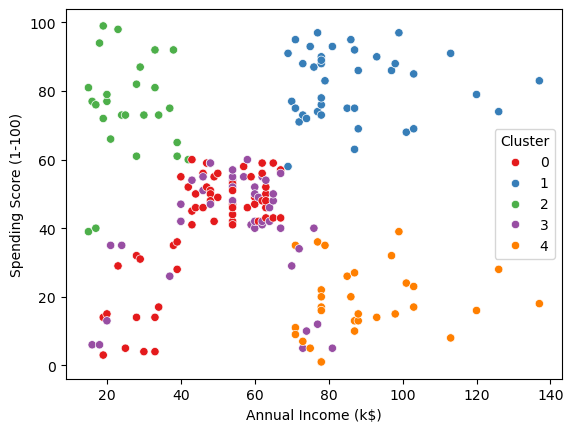

In [39]:
# Visualizing K-Means Clusters

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', 
                hue='Cluster', data=df, palette='Set1')

plt.savefig('kmeans_clusters.png', dpi=300, bbox_inches='tight')

In [41]:
# Cluster Profiling

# Summarize each cluster’s average values to understand their behavior.

df.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


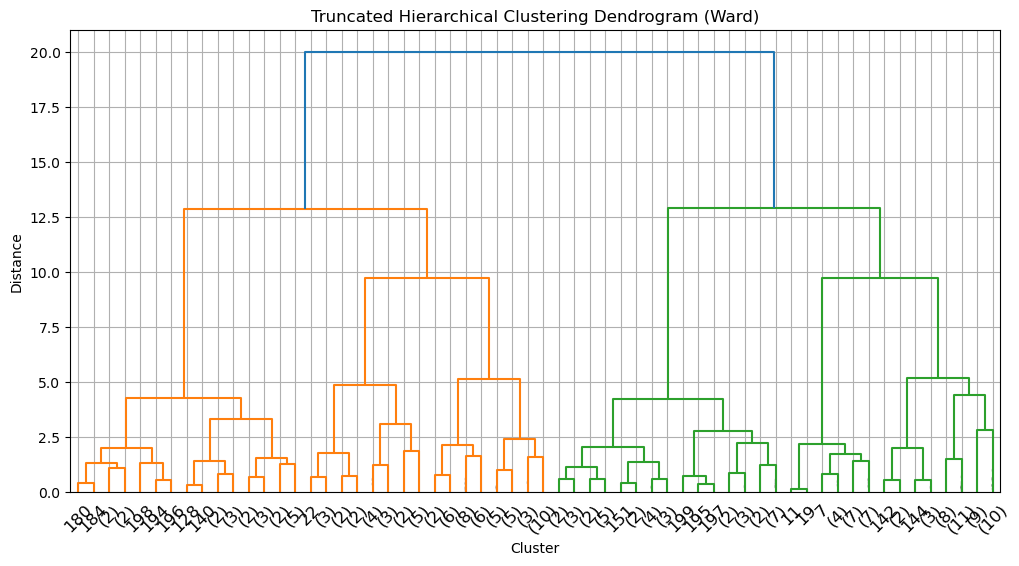

<Figure size 640x480 with 0 Axes>

In [53]:
# Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage
# Compute linkage
Z = linkage(X_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12,6))
dendrogram(
    Z,
    truncate_mode='level',  # only show last 'p' levels
    p=5,                    # number of levels to show
    leaf_rotation=45,       # rotate leaf labels
    leaf_font_size=12,      # font size of leaf labels
    show_contracted=True    # show number of points in contracted branches
)
plt.title('Truncated Hierarchical Clustering Dendrogram (Ward)')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

plt.savefig('hierarchical_dendrogram.png', dpi=300, bbox_inches='tight')

In [55]:
# DBSCAN (Density-Based Clustering)

from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

In [47]:
# SAVE RESULTS

df.to_csv('mall_customers_segmented_final.csv', index=False)